<a href="https://colab.research.google.com/github/omardrag/Food-Optmization-with-gradient-descent/blob/main/gradient_descent_interactivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Gradient Descent Interactivo
### Visualiza cómo el Learning Rate (η) afecta la convergencia
---
Replica exactamente la demo del video de MIT OpenLearning

In [1]:
# ============================================
# CELDA 1: Instalar librerías
# ============================================
!pip install ipywidgets --quiet
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
print('✅ Librerías cargadas')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.6 MB/s eta 0:00:00
✅ Librerías cargadas


## 📊 DEMO 1: Comparación de Learning Rates
Igual que el video — mismos 4 valores de η

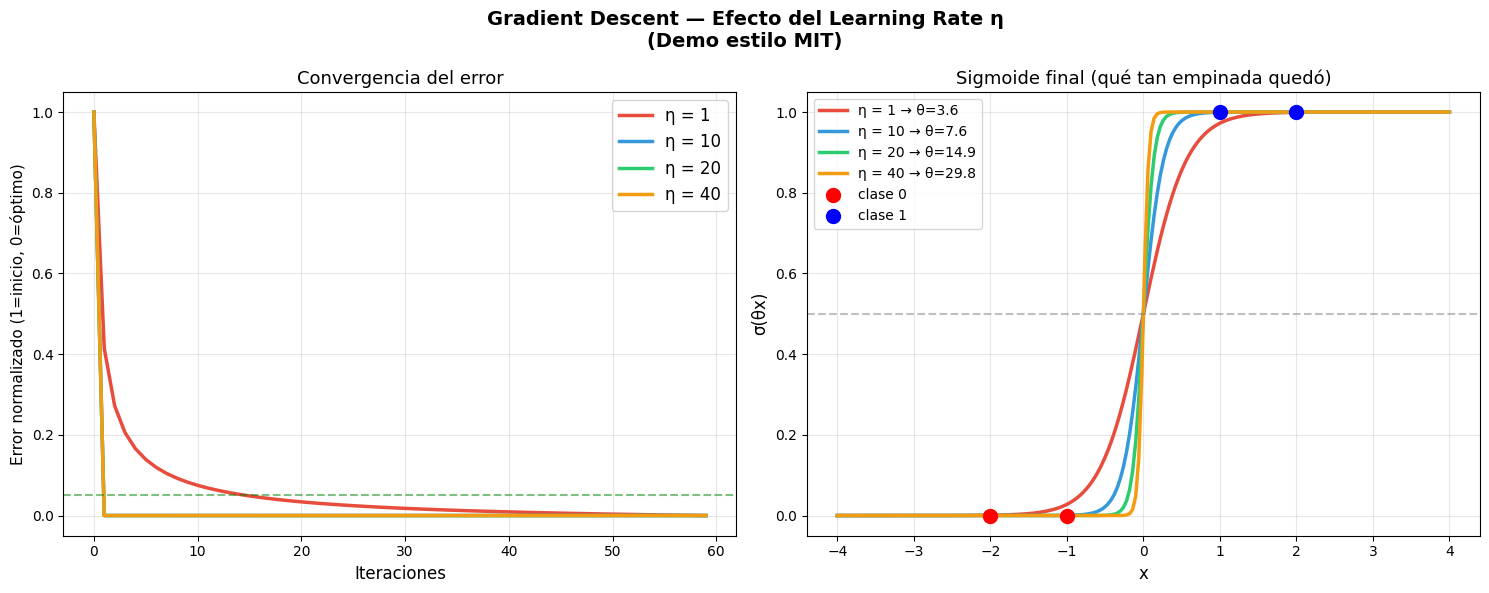


💡 Observa: η más grande → sigmoide más empinada → clasificador más seguro


In [2]:
# ============================================
# CELDA 2: Comparación de 4 learning rates
# ============================================
import numpy as np
import matplotlib.pyplot as plt

# Datos linealmente separables (como en el video MIT)
X = np.array([-2, -1, 1, 2], dtype=float)
y = np.array([0, 0, 1, 1], dtype=float)

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def nll_loss(X, y, theta):
    pred = sigmoid(theta * X)
    pred = np.clip(pred, 1e-10, 1 - 1e-10)
    return -np.mean(y * np.log(pred) + (1 - y) * np.log(1 - pred))

def gradient(X, y, theta):
    pred = sigmoid(theta * X)
    return np.mean((pred - y) * X)

# Probar los mismos step sizes del video
learning_rates = [1, 10, 20, 40]
colores = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
n_iter = 60

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Gradient Descent — Efecto del Learning Rate η\n(Demo estilo MIT)',
             fontsize=14, fontweight='bold')

# Gráfica izquierda: curva de error
ax1 = axes[0]
thetas_finales = {}

for eta, color in zip(learning_rates, colores):
    theta = 0.01
    errores = []

    for _ in range(n_iter):
        loss = nll_loss(X, y, theta)
        errores.append(loss)
        grad = gradient(X, y, theta)
        theta -= eta * grad
        if abs(theta) > 1000:  # evitar divergencia extrema
            theta = np.sign(theta) * 1000

    thetas_finales[eta] = theta
    # Normalizar errores
    errores = np.array(errores)
    e_norm = (errores - errores.min()) / (errores.max() - errores.min() + 1e-10)
    ax1.plot(e_norm, color=color, linewidth=2.5, label=f'η = {eta}')

ax1.set_xlabel('Iteraciones', fontsize=12)
ax1.set_ylabel('Error normalizado (1=inicio, 0=óptimo)', fontsize=11)
ax1.set_title('Convergencia del error', fontsize=13)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0.05, color='green', linestyle='--', alpha=0.5, label='zona óptima')

# Gráfica derecha: la sigmoide resultante para cada η
ax2 = axes[1]
x_plot = np.linspace(-4, 4, 200)

for eta, color in zip(learning_rates, colores):
    theta_f = thetas_finales[eta]
    y_sig = sigmoid(theta_f * x_plot)
    ax2.plot(x_plot, y_sig, color=color, linewidth=2.5, label=f'η = {eta} → θ={theta_f:.1f}')

ax2.scatter(X[:2], y[:2], color='red', s=100, zorder=5, label='clase 0')
ax2.scatter(X[2:], y[2:], color='blue', s=100, zorder=5, label='clase 1')
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('σ(θx)', fontsize=12)
ax2.set_title('Sigmoide final (qué tan empinada quedó)', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print('\n💡 Observa: η más grande → sigmoide más empinada → clasificador más seguro')

## 🎮 DEMO 2: Control Interactivo con Slider
¡Mueve el slider y ve cómo cambia la convergencia en tiempo real!

In [3]:
# ============================================
# CELDA 3: Demo interactiva con sliders
# ============================================
import ipywidgets as widgets
from IPython.display import display, clear_output

out = widgets.Output()

def run_gradient_descent(eta, n_iter, lam):
    theta = 0.01
    errores = []
    thetas = [theta]

    for _ in range(n_iter):
        pred = sigmoid(theta * X)
        grad = np.mean((pred - y) * X) + 2 * lam * theta
        theta -= eta * grad
        if abs(theta) > 2000:
            theta = np.sign(theta) * 2000
        loss = nll_loss(X, y, theta) + lam * theta**2
        errores.append(loss)
        thetas.append(theta)

    return errores, thetas, theta

def plot_interactivo(eta=5.0, n_iter=50, lam=0.0):
    with out:
        clear_output(wait=True)

        errores, thetas, theta_final = run_gradient_descent(eta, n_iter, lam)

        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        fig.suptitle(f'Gradient Descent Interactivo   |   η={eta}   |   λ={lam}   |   iteraciones={n_iter}',
                     fontsize=13, fontweight='bold')

        # 1. Curva de error
        axes[0].plot(errores, color='#e74c3c', linewidth=2.5)
        axes[0].set_title('Error por iteración', fontsize=12)
        axes[0].set_xlabel('Iteración')
        axes[0].set_ylabel('Loss')
        axes[0].grid(True, alpha=0.3)

        # 2. Evolución de θ
        axes[1].plot(thetas, color='#3498db', linewidth=2.5)
        axes[1].set_title('Evolución de θ', fontsize=12)
        axes[1].set_xlabel('Iteración')
        axes[1].set_ylabel('θ')
        axes[1].grid(True, alpha=0.3)
        axes[1].axhline(y=theta_final, color='green', linestyle='--', alpha=0.7,
                        label=f'θ final = {theta_final:.2f}')
        axes[1].legend()

        # 3. Sigmoide final
        x_plot = np.linspace(-4, 4, 200)
        y_sig = sigmoid(theta_final * x_plot)
        axes[2].plot(x_plot, y_sig, color='#2ecc71', linewidth=3)
        axes[2].scatter(X[:2], [0, 0], color='red', s=120, zorder=5, label='clase 0')
        axes[2].scatter(X[2:], [1, 1], color='blue', s=120, zorder=5, label='clase 1')
        axes[2].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
        axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
        axes[2].set_title(f'Sigmoide final (θ={theta_final:.2f})', fontsize=12)
        axes[2].set_xlabel('x')
        axes[2].set_ylabel('P(y=1|x)')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Diagnóstico
        if abs(errores[-1] - errores[-2]) < 0.001:
            print(f'✅ CONVERGIÓ en ~{n_iter} iteraciones | θ final = {theta_final:.3f}')
        else:
            print(f'⚠️ AÚN NO CONVERGIÓ — prueba más iteraciones o reduce η')

        if lam == 0:
            print(f'📌 λ=0: sin regularización → θ puede crecer mucho ({theta_final:.1f})')
        else:
            print(f'📌 λ={lam}: regularización activa → θ controlado ({theta_final:.1f})')

# Sliders
slider_eta = widgets.FloatSlider(value=5, min=0.1, max=50, step=0.5,
                                  description='η (step):', style={'description_width': '100px'},
                                  layout=widgets.Layout(width='500px'))
slider_iter = widgets.IntSlider(value=50, min=5, max=200, step=5,
                                 description='Iteraciones:', style={'description_width': '100px'},
                                 layout=widgets.Layout(width='500px'))
slider_lam = widgets.FloatSlider(value=0, min=0, max=2, step=0.1,
                                  description='λ (reg):', style={'description_width': '100px'},
                                  layout=widgets.Layout(width='500px'))

ui = widgets.VBox([
    widgets.HTML('<h3>🎮 Controles — mueve los sliders</h3>'),
    slider_eta, slider_iter, slider_lam,
    out
])

widgets.interactive_output(plot_interactivo, {
    'eta': slider_eta,
    'n_iter': slider_iter,
    'lam': slider_lam
})

display(ui)
plot_interactivo()  # mostrar inicial

## 🧪 DEMO 3: ¿Qué pasa si η es demasiado grande? (Divergencia)

/tmp/ipykernel_734/3618369768.py:39: UserWarning: Glyph 128034 (\N{TURTLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_734/3618369768.py:39: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_734/3618369768.py:39: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128034 (\N{TURTLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128165 (\N{COLLISION SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

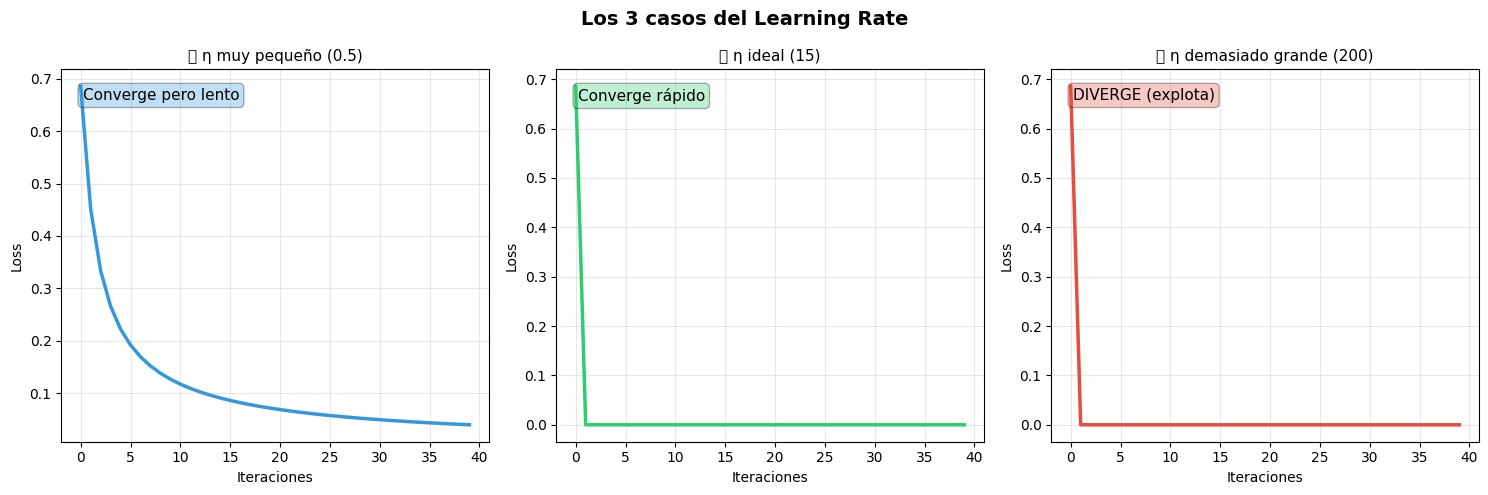

In [4]:
# ============================================
# CELDA 4: Mostrar divergencia
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Los 3 casos del Learning Rate', fontsize=14, fontweight='bold')

casos = [
    {'eta': 0.5,  'title': '🐢 η muy pequeño (0.5)',  'color': '#3498db', 'msg': 'Converge pero lento'},
    {'eta': 15,   'title': '✅ η ideal (15)',           'color': '#2ecc71', 'msg': 'Converge rápido'},
    {'eta': 200,  'title': '💥 η demasiado grande (200)','color': '#e74c3c', 'msg': 'DIVERGE (explota)'},
]

for ax, caso in zip(axes, casos):
    theta = 0.01
    errores = []

    for _ in range(40):
        try:
            loss = nll_loss(X, y, theta)
            if np.isnan(loss) or loss > 1e6:
                errores.append(1e6)
                break
            errores.append(loss)
            grad = gradient(X, y, theta)
            theta -= caso['eta'] * grad
        except:
            errores.append(1e6)
            break

    ax.plot(errores, color=caso['color'], linewidth=2.5)
    ax.set_title(caso['title'], fontsize=11)
    ax.set_xlabel('Iteraciones')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.text(0.05, 0.95, caso['msg'], transform=ax.transAxes,
            fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor=caso['color'], alpha=0.3))

plt.tight_layout()
plt.show()

## 📝 Resumen

| η (Learning Rate) | Resultado |
|---|---|
| Muy pequeño (0.1 - 1) | Converge pero tarda muchas iteraciones |
| Ideal (10 - 20) | Converge rápido y estable |
| Muy grande (100+) | **Diverge** — el error explota |

**λ (Regularización):**
- λ = 0 → θ crece sin límite (overfitting)
- λ grande → θ se queda cerca de 0 (underfitting)
- λ ideal → balance perfecto ✅